# __Taxi-Trip-Duration-EDA__
    ~ Author: Abdallah Salem

    

## Table Of Contents :

- Data Inspection
  - Features Explanation
  - Overall Descriptive Statistics
- Feature Analysis & Feature Engineering
  - Target Feature
  - Numerical Features
  - Categorical Features
  - Time-date Features
- Correlations
    - Numeric features with target
- Conclusions
    - Data Quality
    - Feature Engineering Insights


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Disable warnings 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('split//train.csv')   # load train dataset
val_df = pd.read_csv('Split//val.csv') # load validation dataset

# Data Inspection

In [3]:
df.shape, val_df.shape

((1000000, 10), (229319, 10))

In [4]:
df.info()  # see the columns and their data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1000000 non-null  object 
 1   vendor_id           1000000 non-null  int64  
 2   pickup_datetime     1000000 non-null  object 
 3   passenger_count     1000000 non-null  int64  
 4   pickup_longitude    1000000 non-null  float64
 5   pickup_latitude     1000000 non-null  float64
 6   dropoff_longitude   1000000 non-null  float64
 7   dropoff_latitude    1000000 non-null  float64
 8   store_and_fwd_flag  1000000 non-null  object 
 9   trip_duration       1000000 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 76.3+ MB


### Features Explanation:
- vendor_id
    - a code indicating the provider associated with the trip record
- pikup_datetime
    - date and time when the meter was engaged
- passenger_count
    - the number of passengers in the vehicle (driver who entered the value)
- pikup_logitude
    - the longitude coordinate where the meter was engaged
- pickup_latitude
    - the latitude coordinate where the meter was engaged
- dropoff_longitude
    - the longitude coordinate where the meter was disengaged
- dropoff_latitde
    - the latitude coordinate where the meter was disengaged
- store_and_fwd_flag
    - This flag indicate weather the trip record was held in vehicle memory before sending to the vendor because the vehicle didn't
      have a connection to the server 
        - Y = store and forward
        - N = Not a store and forward trip
- trip duration
    - duration of the trip in seconds (target feature)

#### Observation
- There are no null values
#### Conclusion
- Our Target Feature is trip duration
- id column will be ignored

In [5]:
df.drop(columns=['id'], inplace=True)
val_df.drop(columns=['id'], inplace=True)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,1000000.0,1.534793,0.498788,1.000000,1.000000,2.000000,2.000000,2.000000e+00
passenger_count,1000000.0,1.665353,1.315723,0.000000,1.000000,1.000000,2.000000,7.000000e+00
pickup_longitude,1000000.0,-73.973475,0.065404,-121.933342,-73.991852,-73.981728,-73.967346,-6.133553e+01
pickup_latitude,1000000.0,40.750947,0.033745,34.359695,40.737372,40.754131,40.768379,5.188108e+01
dropoff_longitude,1000000.0,-73.973421,0.065432,-121.933304,-73.991341,-73.979767,-73.963036,-6.133553e+01
dropoff_latitude,1000000.0,40.751829,0.035782,34.359695,40.735928,40.754551,40.769833,4.392103e+01
trip_duration,1000000.0,954.884971,3882.070116,1.000000,397.000000,662.000000,1074.000000,2.227612e+06


#### Observation
- Passenger_count has value 7 ??
- According to NYC coordinates there are some records for pickup and dropoff which are out of range
- Trip duration has some nonreasonable values of durations (max value 2227612 seconds ??)

#### Conclusion
- Data has outliers

# Feature Analysis & Feature Engineering

## 1. Target Feature Analysis

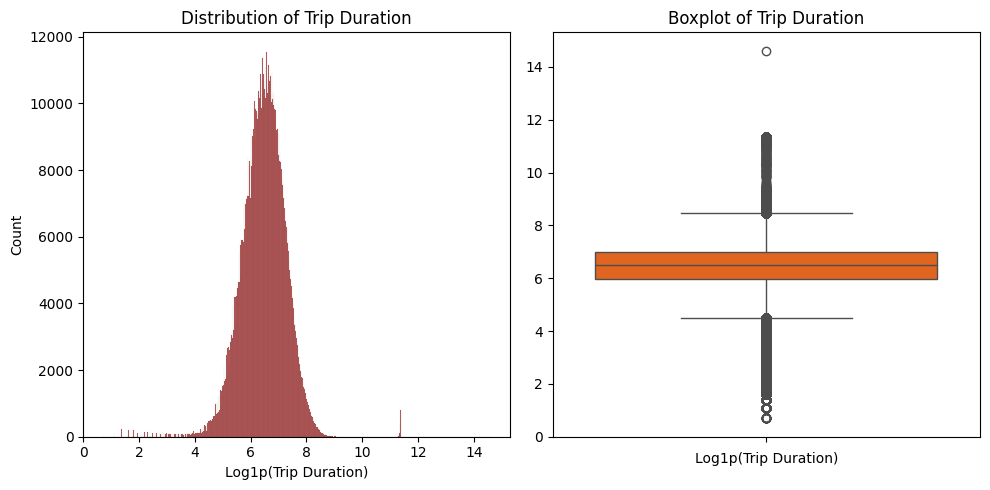

In [7]:
# let's visualize out target feature and get some insights
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

log1p_duration = np.log1p(df['trip_duration'].values)  #log transformation to kill skewness, easy to visualize

sns.histplot(log1p_duration, color='brown', ax=axes[0])
axes[0].set_title('Distribution of Trip Duration')
axes[0].set_xlabel('Log1p(Trip Duration)')

sns.boxplot(log1p_duration, palette='hot' , ax=axes[1])
axes[1].set_title('Boxplot of Trip Duration')
axes[1].set_xlabel('Log1p(Trip Duration)')


plt.tight_layout()
plt.show()

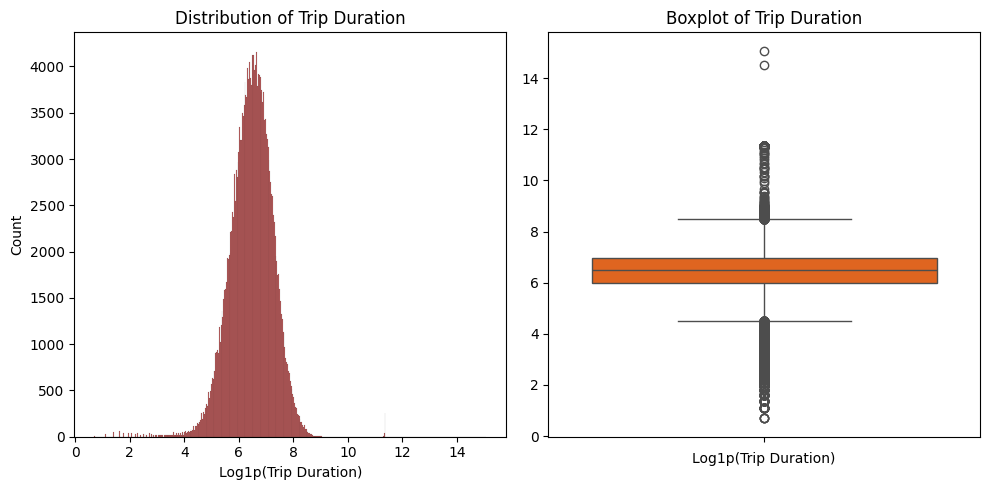

In [8]:
# let's visualize out target feature and get some insights
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

val_log1p_duration = np.log1p(val_df['trip_duration'].values)
sns.histplot(val_log1p_duration, color='brown', ax=axes[0])
axes[0].set_title('Distribution of Trip Duration')
axes[0].set_xlabel('Log1p(Trip Duration)')

sns.boxplot(val_log1p_duration, palette='hot' , ax=axes[1])
axes[1].set_title('Boxplot of Trip Duration')
axes[1].set_xlabel('Log1p(Trip Duration)')


plt.tight_layout()
plt.show()

#### Observations
- Target feature after log transformation it's distribution seems to be normal
- Some outliers appeared on the plots, I'll remove them

In [9]:
df_clean = df[(df['trip_duration'] > 60)  & (df['trip_duration'] < 24*60*60)].copy()
val_df_clean = val_df[(val_df['trip_duration'] > 60)  & (val_df['trip_duration'] < 24*60*60)].copy()

## 2. Numerical Features Analysis

### 2.1. Discrete Numerical Features 

In [10]:
# let's investigate unique values and their frequencies
df['vendor_id'].value_counts(), df['passenger_count'].value_counts()

(vendor_id
 2    534793
 1    465207
 Name: count, dtype: int64,
 passenger_count
 1    708628
 2    143907
 5     53635
 3     41012
 6     33287
 4     19491
 0        38
 7         2
 Name: count, dtype: int64)

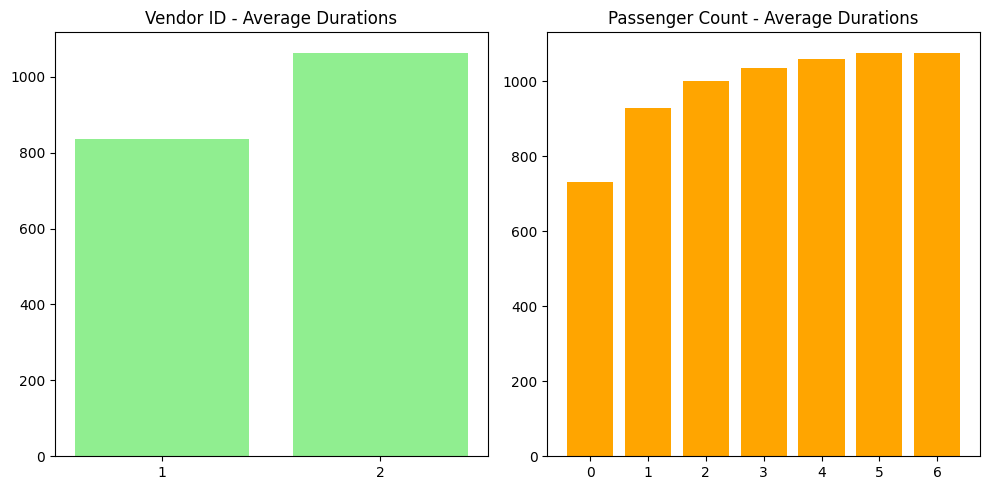

In [11]:
vendor_table = df_clean.groupby('vendor_id').agg({'trip_duration':'mean'})
passenger_table = df_clean.groupby('passenger_count').agg({'trip_duration':'mean'})


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

axes[0].bar(vendor_table.index.astype(str), vendor_table['trip_duration'], color='lightgreen')
axes[0].set_title('Vendor ID - Average Durations')

axes[1].bar(passenger_table.index.astype(str), passenger_table['trip_duration'], color='orange')
axes[1].set_title('Passenger Count - Average Durations')

plt.tight_layout()
plt.show()

#### Observations
- Passenger counts 1,2,3,4,5,6 have fair average durations while 0 & 7 not
- vendor_id(2) has longer avg trips than vendor_id(1)
#### Thoughts
- passenger count(7) disappeared after removing outliers of target feature
- passenger count(0) has fair avg trip duration
- passenger count(0) may be on purpose which are specific cases (may not help our model)

### 2.2. Geographical Numerical features

In [12]:
# I'll drop points which are out of range, may be an early decision.
df_clean = df_clean[(df_clean['pickup_longitude'] >= -74.26) & (df_clean['pickup_longitude'] <= -73.70)]
df_clean = df_clean[(df_clean['dropoff_longitude'] >= -74.26) & (df_clean['dropoff_longitude'] <= -73.70)]
df_clean = df_clean[(df_clean['pickup_latitude'] >= 40.50) & (df_clean['pickup_latitude'] <= 40.92)]
df_clean = df_clean[(df_clean['dropoff_latitude'] >= 40.50) & (df_clean['dropoff_latitude'] <= 40.92)]

# let's do this for val dataset
val_df_clean = val_df_clean[(val_df_clean['pickup_longitude'] >= -74.26) & (val_df_clean['pickup_longitude'] <= -73.70)]
val_df_clean = val_df_clean[(val_df_clean['dropoff_longitude'] >= -74.26) & (val_df_clean['dropoff_longitude'] <= -73.70)]
val_df_clean = val_df_clean[(val_df_clean['pickup_latitude'] >= 40.50) & (val_df_clean['pickup_latitude'] <= 40.92)]
val_df_clean = val_df_clean[(val_df_clean['dropoff_latitude'] >= 40.50) & (val_df_clean['dropoff_latitude'] <= 40.92)]

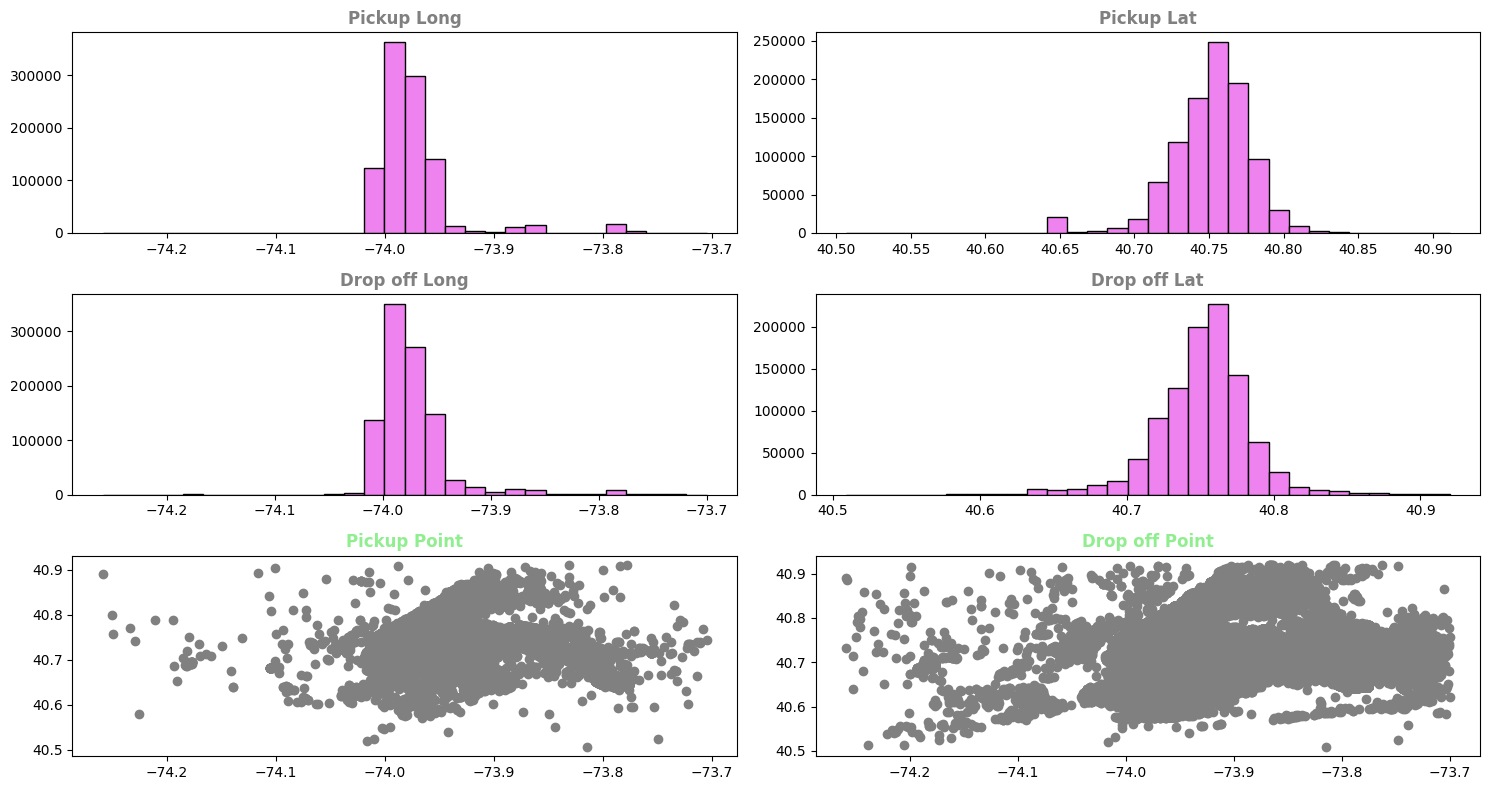

In [13]:
# let's visualize the distibution of the geo features
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15,8))

axes[0,0].hist(df_clean['pickup_longitude'], bins=30, color='violet', edgecolor='black')
axes[0,0].set_title('Pickup Long', weight='bold', color='grey')

axes[0,1].hist(df_clean['pickup_latitude'], bins=30, color='violet', edgecolor='black')
axes[0,1].set_title('Pickup Lat', weight='bold', color='grey')

axes[1,0].hist(df_clean['dropoff_longitude'], bins=30, color='violet', edgecolor='black')
axes[1,0].set_title('Drop off Long', weight='bold', color='grey')

axes[1,1].hist(df_clean['dropoff_latitude'], bins=30, color='violet', edgecolor='black')
axes[1,1].set_title('Drop off Lat', weight='bold', color='grey')

axes[2,0].scatter(df_clean['pickup_longitude'], df_clean['pickup_latitude'], color='grey')
axes[2,0].set_title('Pickup Point', weight='bold', color='lightgreen')

axes[2,1].scatter(df_clean['dropoff_longitude'], df_clean['dropoff_latitude'], color='grey')
axes[2,1].set_title('Drop off Point', weight='bold', color='lightgreen')


plt.tight_layout()
plt.show()

#### Observations
- Most of pickups and drops from (-74.2, 40.5) to (-73.8, 40.9)
- Dropoff latitude & pickup latitude seems to be normal data

#### Thoughts
- These trips are in boroughs which have highest number of taxis ,passengers and crowd


In [14]:
# let's calculate geo distance
def haversine_distance(pick_lat, pick_long, drop_lat, drop_long):
    
    """Calculate distance in km using vectorized operations"""
    
    radius = 6371  # Radius of Earth (km)
    pick_lat_rad, pick_long_rad = np.radians(pick_lat), np.radians(pick_long)
    drop_lat_rad, drop_long_rad = np.radians(drop_lat), np.radians(drop_long)
    
    dlat = drop_lat_rad - pick_lat_rad
    dlong = drop_long_rad - pick_long_rad
    
    a = np.sin(dlat/2)**2 + np.cos(pick_lat_rad) * np.cos(drop_lat_rad) * np.sin(dlong/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return radius * c

# get geo distance and it as a feature to the dataset
df_clean['haversine_distance'] = haversine_distance(df_clean['pickup_latitude'], df_clean['pickup_longitude'],
                                      df_clean['dropoff_latitude'], df_clean['dropoff_longitude'])

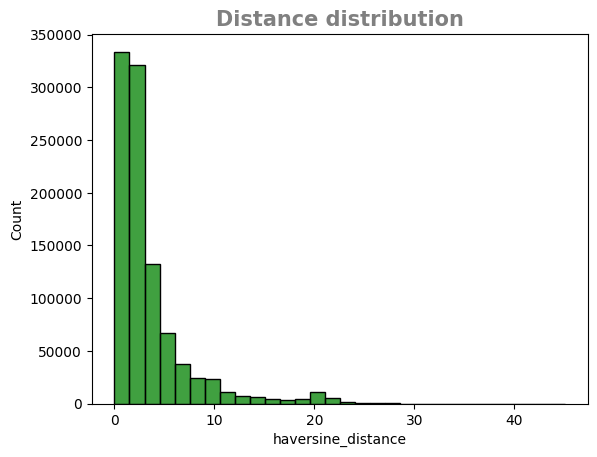

In [15]:
sns.histplot(df_clean['haversine_distance'], bins=30, color='green')
plt.title('Distance distribution', weight='bold', size='15', color='grey')
plt.show()

#### Observations
- Data is right skewed may it need to have log transformation
- There are some distances which are zero and near to zero ???
#### Thoughts
- May small distances are for purpose or under some circumstances
- Zero distance because that the start point of the trip is the end point or
  the driver left the car for any reason while he initiated the meter and when came back he noticed
  and stopped it.

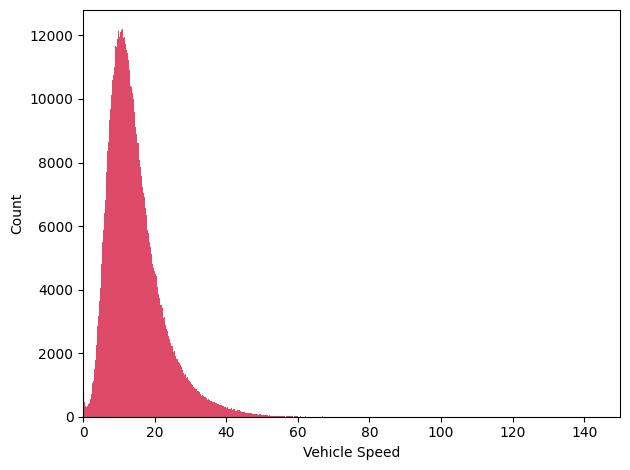

In [16]:
# let's get the speed of each trip and investigate
trip_speed = df_clean['haversine_distance'] / (df_clean['trip_duration'] / 3600)

sns.histplot(trip_speed, color='crimson')
plt.xlim(0, 150)
plt.xlabel('Vehicle Speed')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Observations
- Speeds range between 10km to 40km
#### Thougts
- Traffics and crowd streets

## 3. Categorical Feature Analysis

In [17]:
# we have one categorical feature which is store & fwd flag
df_clean['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    987809
Y      5450
Name: count, dtype: int64

#### Observations
- It seems that most trips were connected to the server
#### Thoughts
- There are some reasons for disconnection with the server:
    - The vehicle passed through a tunnel or a place where connection lost
    - Problem in the vehicle itself
    - Problem in the server

## 4. Time-Date Feature Analysis

In [18]:
df_clean['pickup_datetime'] = df_clean['pickup_datetime'].astype('datetime64[ns]')

# Let's investigate date time column
df_clean['year'] = df_clean['pickup_datetime'].dt.year
df_clean['month'] = df_clean['pickup_datetime'].dt.month
df_clean['dayofweek'] = df_clean['pickup_datetime'].dt.dayofweek
df_clean['hour'] = df_clean['pickup_datetime'].dt.hour
df_clean['quarter'] = df_clean['pickup_datetime'].dt.quarter

In [19]:
df_clean['year'].unique(),  df_clean['quarter'].unique(), df_clean['month'].unique(), df_clean['dayofweek'].unique() , df_clean['hour'].unique()

(array([2016], dtype=int32),
 array([2, 1], dtype=int32),
 array([6, 4, 5, 3, 2, 1], dtype=int32),
 array([2, 6, 3, 4, 1, 0, 5], dtype=int32),
 array([ 7, 12,  2, 17, 21,  6, 14, 23, 22,  8, 18, 20, 16, 19, 10,  0, 11,
        15, 13,  1,  9,  3,  5,  4], dtype=int32))

#### Observations
- Only year 2016
- Only two quarters
- Only month [1, 2, 3, 4, 5, 6]
- All days and all hours are recorded with good percentages
#### Thoughts
- Feature isn't representative enough (narrow diversity)
- This may mislead the model

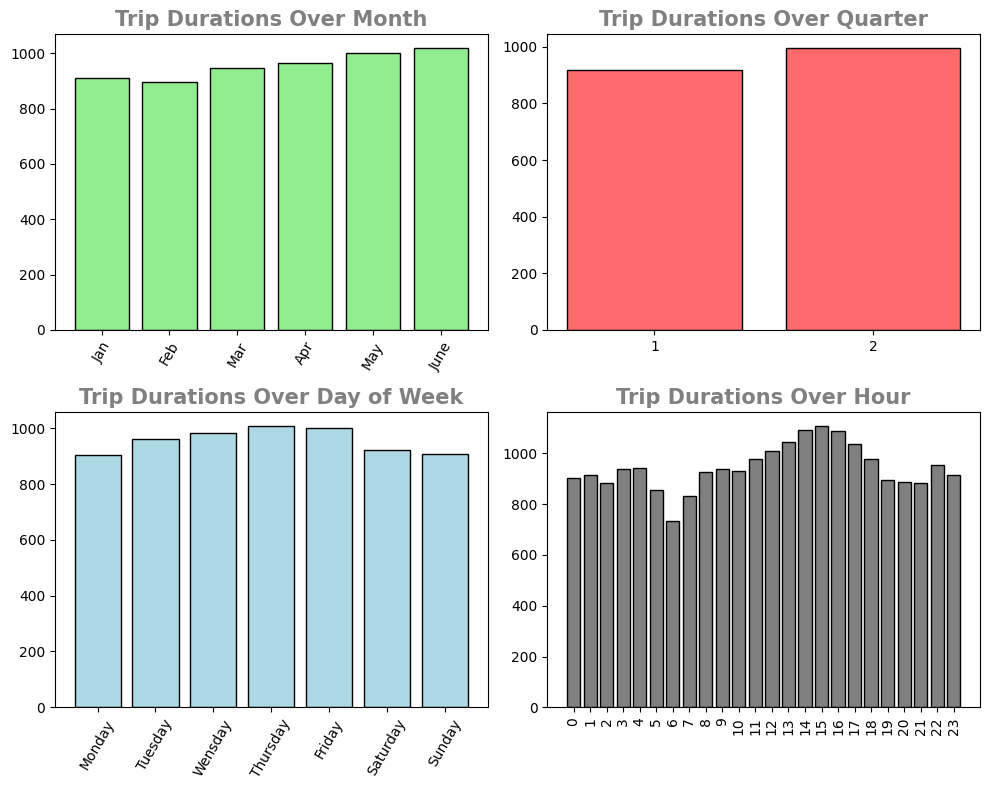

In [20]:
# visualizing trip durations over months, quarters, days of the week and hours using matplot lib

month_table = df_clean.groupby(['month']).agg({'trip_duration': 'mean'})
quarter_table = df_clean.groupby(['quarter']).agg({'trip_duration':'mean'})
day_table = df_clean.groupby(['dayofweek']).agg({'trip_duration':'mean'})
hour_table = df_clean.groupby(['hour']).agg({'trip_duration':'mean'})

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,8))

days = ['Monday', 'Tuesday', 'Wensday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June']



axes[0,0].bar(month_table.index.astype(str), month_table['trip_duration'], color='lightgreen', edgecolor='black')
axes[0,0].set_title('Trip Durations Over Month', weight='bold', size=15, color='grey')
axes[0,0].set_xticks(ticks=month_table.index.astype(str), labels=months, rotation=60)

axes[0,1].bar(quarter_table.index.astype(str), quarter_table['trip_duration'], color='#FF6B6B', edgecolor='black')
axes[0,1].set_title('Trip Durations Over Quarter', weight='bold', size=15, color='grey')

axes[1,0].bar(day_table.index, day_table['trip_duration'], color='lightblue', edgecolor='black')
axes[1,0].set_title('Trip Durations Over Day of Week', weight='bold', size=15, color='grey')
axes[1,0].set_xticks(ticks=day_table.index, labels=days, rotation=60)

axes[1,1].bar(hour_table.index.astype(str), hour_table['trip_duration'], color='grey', edgecolor='black')
axes[1,1].set_title('Trip Durations Over Hour', weight='bold', size=15, color='grey')
axes[1,1].set_xticks(ticks=hour_table.index, labels=hour_table.index.astype(str), rotation=90)

plt.tight_layout()
plt.show()


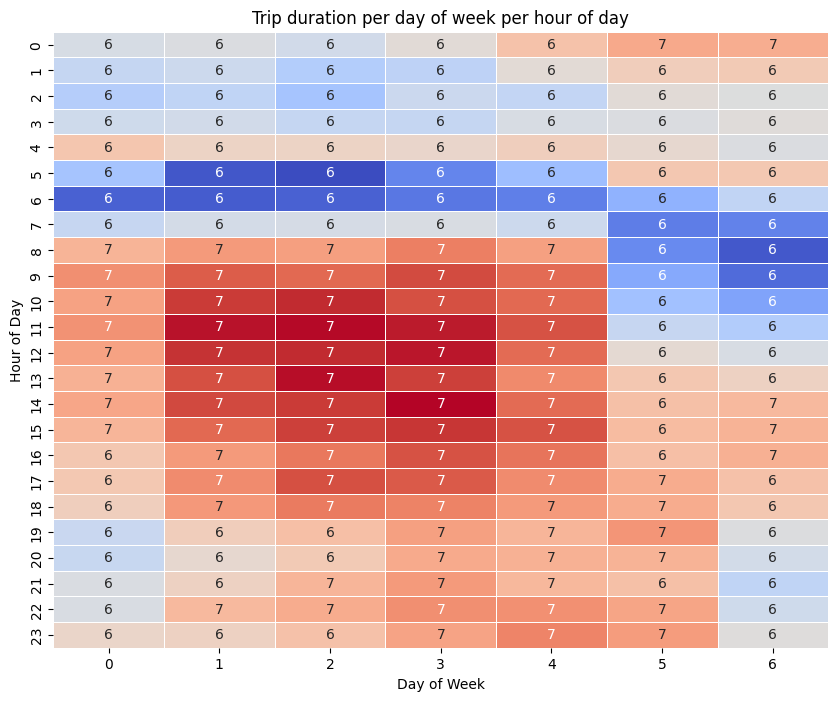

In [21]:
# visualizing using pivot table and heat map feature to understand more about trip durations with different times

date_time = df_clean[['month','hour','dayofweek','quarter']].copy()
date_time['trip_duration'] = np.log1p(df['trip_duration'])  #log transformed trip duration (killing the skewness)
table = pd.pivot_table(
    date_time, 
    values='trip_duration', 
    index='hour',
    columns='dayofweek', 
    aggfunc="median"
)

plt.figure(figsize=(10,8))
ax = sns.heatmap(table, annot=True, fmt='.0f', cmap='coolwarm', linewidths='0.5', cbar=False)
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.title('Trip duration per day of week per hour of day')
plt.show()

#### Observations
- Months 5, 6 have highest average trip durations (Summer)
- second Quarter has the highest average trip durations
- Tuesday, Wensday, Thursday, Friday have the highest average trip durations (not weekend)
- from 11am to 5pm the highest trip durations (Afternoon)
#### Thoughts
- Adding new features like (weekend, parts of day, seasons) will help more with the model

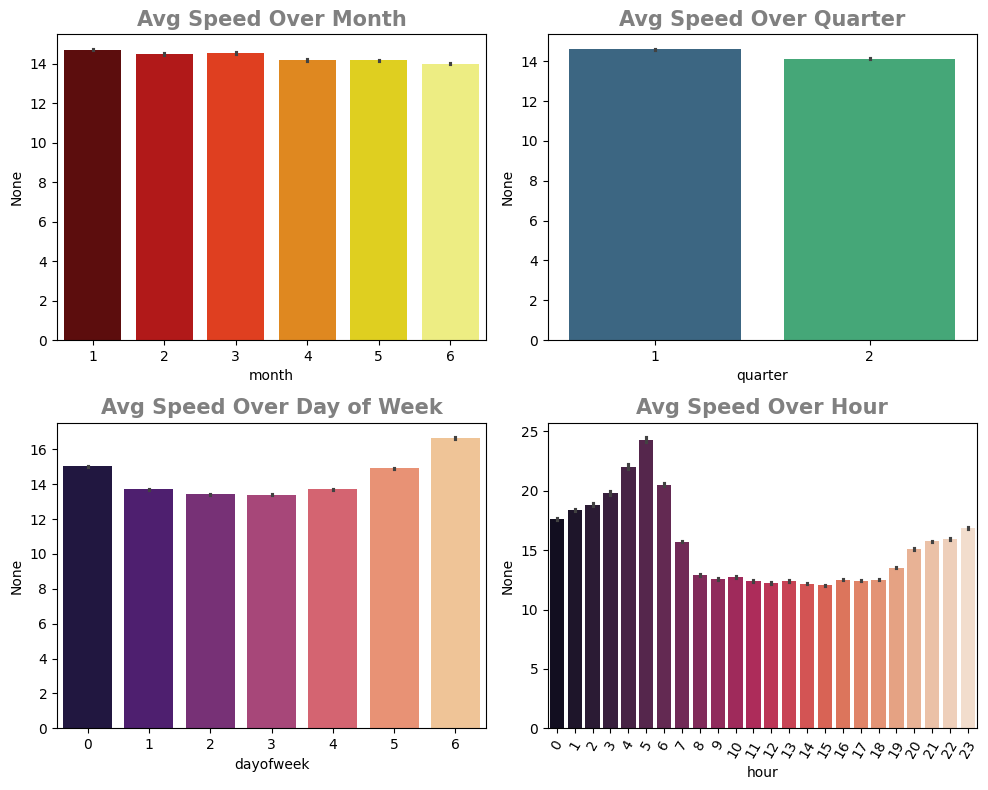

In [22]:
# visualizing average speed over months, hours, quarters and days of the week using seaborn lib

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,8))


sns.barplot(data=df_clean, x='month', y=trip_speed, palette='hot', ax=axes[0,0])
axes[0,0].set_title('Avg Speed Over Month', weight='bold', size=15, color='grey')

sns.barplot(data=df_clean, x='quarter', y=trip_speed, palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Avg Speed Over Quarter', weight='bold', size=15, color='grey')

sns.barplot(data=df_clean, x='dayofweek', y=trip_speed, palette='magma', ax=axes[1,0])
axes[1,0].set_title('Avg Speed Over Day of Week', weight='bold', size=15, color='grey')

sns.barplot(data=df_clean, x='hour', y=trip_speed, palette='rocket', ax=axes[1,1])
axes[1,1].set_title('Avg Speed Over Hour', weight='bold', size=15, color='grey')
axes[1,1].set_xticks(ticks=df_clean['hour'].unique(), labels=df_clean['hour'].unique(), rotation=60)

plt.tight_layout()
plt.show()


#### Observations
- Low avg speed in months 4, 5, 6 which are in automn & summer seasons
- Low avg speed in tuesday, wendsday, thursday, friday not weekend
- low avg spped at 8am to 7pm in the day
#### Thoughts
- We have rush hours in a day, we need to find busy streets or boroughs or areas

## 5. Correlations

### 5.1. Numeric Features with target

In [23]:
df_clean.columns

Index(['vendor_id', 'pickup_datetime', 'passenger_count', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'store_and_fwd_flag', 'trip_duration', 'haversine_distance', 'year',
       'month', 'dayofweek', 'hour', 'quarter'],
      dtype='object')

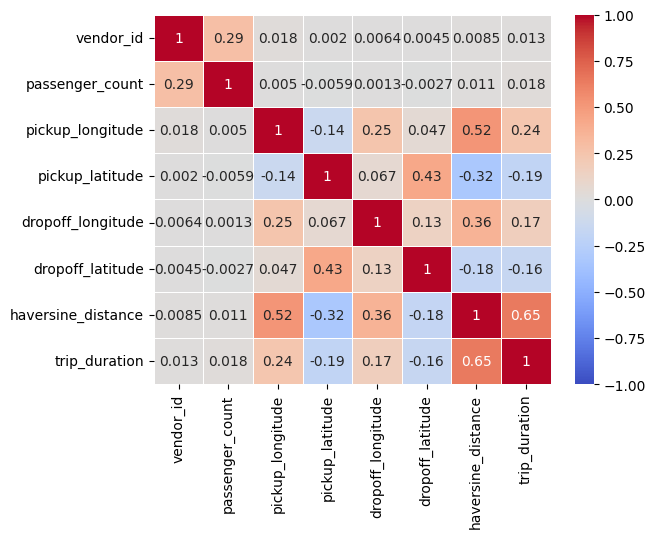

<Figure size 1200x400 with 0 Axes>

In [24]:
# correlations between numeric features and target feature
numeric_feat = ['vendor_id','passenger_count','pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude', 'haversine_distance']
df_corr = df_clean[numeric_feat]
df_corr['trip_duration'] = np.log1p(df['trip_duration'])
corr = df_corr.corr()
sns.heatmap(corr,annot=True,linewidths=.5,cmap='coolwarm',vmin=-1,vmax=1,center=0)
fig = plt.figure(figsize=(12,4))
plt.show()

#### Observations
- The highest correlation is between haversine_distance and target (0.63)

## 6. Conclusions

### 6.1. Data Quality
- As we found before date-time feature isn't more representative (narrow diversity), the model may not generalize
- This problem needs more data like boroughs and subboroughs with their coordinates of NYC which will help to give a good path to the trip (from, to)

### 6.2. Feature Engineering Insights
- Adding Season Features (Summer, Winter, Automn, Spring)
- Adding Days of the week features and is weekend or not features
- Adding Parts of the day features (Morning, Afternoon, Evening, Night)
- Adding direction(angles) Features
- Adding boroughs & subboroughs Features (trip path, busy subboroughs or streets)
- Some features are skewed which need transformation (log transformation or others)
- Encoding methods for discrete numeric features (OneHotEncoding or others)